In [1]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
from astropy import wcs
from astropy.table import Table, vstack
import astropy.units as u
import regions
import numpy as np
from matplotlib.lines import Line2D
from astropy.wcs import WCS
from regions import Regions, RectangleSkyRegion
import corner



In [2]:
image_filenames_pipe ={
    "f150w": "/orange/adamginsburg/jwst/sgrb2/NB/F150W/pipeline/jw05365-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/sgrb2/NB/F182M/pipeline/jw05365-o001_t001_nircam_clear-f182m-merged_i2d.fits", 
    "f187n": "/orange/adamginsburg/jwst/sgrb2/NB/F187N/pipeline/jw05365-o001_t001_nircam_clear-f187n-merged_i2d.fits", 
    "f210m": "/orange/adamginsburg/jwst/sgrb2/NB/F210M/pipeline/jw05365-o001_t001_nircam_clear-f210m-merged_i2d.fits", 
    "f212n": "/orange/adamginsburg/jwst/sgrb2/NB/F212N/pipeline/jw05365-o001_t001_nircam_clear-f212n-merged_i2d.fits", 
    "f300m": "/orange/adamginsburg/jwst/sgrb2/NB/F300M/pipeline/jw05365-o001_t001_nircam_clear-f300m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/sgrb2/NB/F360M/pipeline/jw05365-o001_t001_nircam_clear-f360m-merged_i2d.fits", 
    "f405n": "/orange/adamginsburg/jwst/sgrb2/NB/F405N/pipeline/jw05365-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/sgrb2/NB/F410M/pipeline/jw05365-o001_t001_nircam_clear-f410m-merged_i2d.fits", 
    "f466n": "/orange/adamginsburg/jwst/sgrb2/NB/F466N/pipeline/jw05365-o001_t001_nircam_clear-f466n-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/sgrb2/NB/F480M/pipeline/jw05365-o001_t001_nircam_clear-f480m-merged_i2d.fits", 
    "f410m-f405n": "/orange/adamginsburg/jwst/sgrb2/NB/filter_subtractions/f405n_minus_f410m.fits",
    "f405n-f410m": "/orange/adamginsburg/jwst/sgrb2/NB/filter_subtractions/f405n_minus_f410m.fits",
    "f770w": "/orange/adamginsburg/jwst/sgrb2/NB/pipeline_reruns/MIRI_for_images_try2/jw05365-o002_t002_miri_f770w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/sgrb2/NB/pipeline_reruns/MIRI_for_images_try2/jw05365-o002_t002_miri_f1280w_i2d.fits",
    'f2550W': "/orange/adamginsburg/jwst/sgrb2/NB/pipeline_reruns/MIRI_for_images_try2/jw05365-o002_t002_miri_f2550w_i2d.fits",
}

In [3]:
test_regions = regions.Regions.read("/orange/adamginsburg/jwst/sgrb2/NB/sgrb2_jwst/by_eye_catalogs/catalog_refinment_test_regions.crtf", format="crtf") 

In [4]:
test_region1 = test_regions[0]
test_region2 = test_regions[1]

In [5]:
#regs_region_combined = Regions(list(regs_region1) + list(regs_region2))

In [6]:
def subset_catalog_in_region(cat, regions, filt=None):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FITSFixedWarning)
        if f'skycoord{filt}' not in cat.colnames:
            coords = cat['skycoord']
        else:
            coords = cat[f'skycoord{filt}']
        # Start with all False
        mask = np.zeros(len(cat), dtype=bool)
        if isinstance(regions, RectangleSkyRegion):
            mask |= regions.contains(coords, wcs=wcs.WCS(fits.getheader(image_filenames_pipe[filt], ext=1)))
        else:
            for r in regions:
                # Update mask to include points inside this region
                mask |= r.contains(coords, wcs=wcs.WCS(fits.getheader(image_filenames_pipe[filt], ext=1)))
                
        return cat[mask]

In [7]:
def build_plot_columns(cat, filt):
    if f'skycoord{filt}' not in cat.colnames:
        suffix = ""
    else:
        suffix = f"_{filt.lower()}"

    flux_fit = cat[f"flux_fit{suffix}"]
    flux_err = cat[f"flux_err{suffix}"]

    plot_cols = {
        "local_bkg": cat[f"local_bkg{suffix}"],
        "flux_err": flux_err,
        "flux_fit": flux_fit,
        "qfit": cat[f"qfit{suffix}"],
        "cfit": cat[f"cfit{suffix}"],
        "roundness1": cat[f"roundness1{suffix}"],
        "roundness2": cat[f"roundness2{suffix}"],
        "sharpness": cat[f"sharpness{suffix}"],
        "SNR": flux_fit / flux_err,
        #"SNR": flux_fit / cat[f"local_bkg{suffix}"],
        "nmatch": cat[f"nmatch{suffix}"],
        "nmatch_good": cat[f"nmatch_good{suffix}"],
    }

    return plot_cols

In [8]:
def plot_pair_matrix(cat_region, cat_matched, filt,
                     title="", log_upper_triangle=True, after_selection=False):

    plot_cols = build_plot_columns(cat_region, filt)
    plot_cols_matched = build_plot_columns(cat_matched, filt)

    cols = list(plot_cols.keys())
    n = len(cols)

    fig, axes = plt.subplots(n, n, figsize=(18, 18),
                             constrained_layout=True)

    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):

            ax = axes[i, j]

            x_all = plot_cols[col2]
            y_all = plot_cols[col1]

            x_match = plot_cols_matched[col2]
            y_match = plot_cols_matched[col1]

            if after_selection:
                ax.scatter(x_all, y_all, s=5, c="blue", alpha=0.8)
                ax.scatter(x_match, y_match, s=3, c="red", alpha=0.8)
            else:
                ax.scatter(x_all, y_all, s=3, c="k", alpha=0.8)
                ax.scatter(x_match, y_match, s=3, c="red", alpha=0.8)

            if log_upper_triangle and j > i:
                ax.set_xscale("log")
                ax.set_yscale("log")

            ax.tick_params(axis='both', which='both',
                           top=False, bottom=False,
                           left=False, right=False,
                           labeltop=False, labelbottom=False,
                           labelleft=False, labelright=False)

            if i == 0:
                ax.tick_params(axis='x', which='both',
                               top=True, labeltop=True)
                ax.xaxis.set_label_position('top')
                ax.set_xlabel(col2)

            if i == n - 1:
                ax.tick_params(axis='x', which='both',
                               bottom=True, labelbottom=True)
                ax.set_xlabel(col2)

            if j == 0:
                ax.tick_params(axis='y', which='both',
                               left=True, labelleft=True)
                ax.set_ylabel(col1)

            if j == n - 1:
                ax.tick_params(axis='y', which='both',
                               right=True, labelright=True)
                ax.yaxis.set_label_position('right')
                ax.set_ylabel(col1)

    fig.suptitle(title, fontsize=16)

    if after_selection:
        legend_elements = [
            Line2D([0], [0], marker='x', color='w',
                   markerfacecolor='cyan', markersize=6, label='daophot after selection'),
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='red', markersize=6, label='by_eye'),
        ]
    else:  
        legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                markerfacecolor='blue', markersize=6, label='daophot'),
            Line2D([0], [0], marker='o', color='w',
                markerfacecolor='red', markersize=6, label='by_eye'),
        ]

    fig.legend(handles=legend_elements)

    return fig, axes

In [9]:
def match_regions_to_catalog(cat, regions_list, 
                             filt,
                             max_sep=0.1*u.arcsec):
    matched_indices = []
    if f'skycoord{filt}' not in cat.colnames:
        coords = cat['skycoord']
    else:
        coords = cat[f'skycoord{filt}']

    for reg in regions_list:
        idx, sep2d, _ = reg.center.match_to_catalog_sky(coords)
        if sep2d < max_sep:
            matched_indices.append(idx)

    return cat[matched_indices]

In [10]:

from astropy.nddata import Cutout2D
def get_region_cutout(filt, region, ext=1, pad_factor=1.05):
    """
    Returns (cutout_data, cutout_wcs) covering the full extent of `region`.
    pad_factor slightly enlarges the box.
    """
    image_path = image_filenames_pipe[filt]
    wcs_obj = WCS(fits.getheader(image_path, ext=ext))
    data = fits.getdata(image_path, ext=ext)
    full_wcs = WCS(fits.getheader(image_path, ext=ext))

    # Convert region to pixel coordinates
    pix_region = region.to_pixel(full_wcs)

    # Bounding box in pixel coordinates
    xmin, xmax = pix_region.bounding_box.ixmin, pix_region.bounding_box.ixmax
    ymin, ymax = pix_region.bounding_box.iymin, pix_region.bounding_box.iymax

    xsize = (xmax - xmin) * pad_factor
    ysize = (ymax - ymin) * pad_factor

    xcen = 0.5 * (xmin + xmax)
    ycen = 0.5 * (ymin + ymax)

    cutout = Cutout2D(
        data,
        position=(xcen, ycen),
        size=(ysize, xsize),
        wcs=full_wcs
    )

    return cutout.data, cutout.wcs

In [11]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

def plot_spatial_detections(image_data, image_wcs,
                            cat_region,
                            cat_matched,
                            title="",
                            filt="",
                            selected_cat = None):

    if filt != "":
        suffix = f"_{filt.lower()}"
    else:
        suffix = ""

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection=image_wcs)

    norm = simple_norm(image_data, stretch='log', percent=99.5)
    ax.imshow(image_data, origin='lower', norm=norm, cmap='gray')

    # mask = cat_region[f"nmatch{suffix}"] >= (np.nanmax(cat_region[f"nmatch{suffix}"])/2+1)
    # print(f"Number of sources with nmatch >= max/2+1: {np.sum(mask)}")
    # print(f"Total number of sources in region: {len(cat_region)}")
    # skycoords_nmatch = cat_region[f"skycoord{suffix}"][mask]
    # x_nmatch, y_nmatch = skycoords_nmatch.to_pixel(image_wcs)
    # ax.scatter(x_nmatch, y_nmatch, color = 'cyan', marker = '+', s = 30, label='nmatch=>max/2+1')
    # skycoords_masked = cat_in_region_masked[f"skycoord{suffix}"]
    # x_masked, y_masked = skycoords_masked.to_pixel(image_wcs)
    # ax.scatter(x_masked, y_masked, color = 'cyan', marker = '+', s = 30, label='masked')
    
    if selected_cat is not None:
        skycoords_extra = selected_cat[f"skycoord{suffix}"]
        x_extra, y_extra = skycoords_extra.to_pixel(image_wcs)
        ax.scatter(x_extra, y_extra, color = 'cyan', marker = 'x', s = 30, label='selected')

    # All detections in region
    skycoords_all = cat_region[f"skycoord{suffix}"]
    x_all, y_all = skycoords_all.to_pixel(image_wcs)
    print(f"Number of daophot sources: {len(x_all)}")
    ax.scatter(x_all, y_all, marker = 'o', s = 10, edgecolors = 'blue', facecolors = 'none', label='daophot')

    # By-eye matched
    skycoords_match = cat_matched[f"skycoord{suffix}"]
    print(f"Number of by-eye matched sources: {len(skycoords_match)}")
    x_match, y_match = skycoords_match.to_pixel(image_wcs)
    ax.scatter(x_match, y_match, color = 'red', marker = '.', s = 10, label='by_eye')

    # place legend just outside the axes at the top-right
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0., frameon=True)

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    ax.set_title(title)

    return fig, ax

In [12]:
filt = 'f212n'
cat_a_before_merging = Table.read(f'/orange/adamginsburg/jwst/sgrb2/NB//catalogs/{filt}_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits')
cat_b_before_merging = Table.read(f'/orange/adamginsburg/jwst/sgrb2/NB//catalogs/{filt}_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits')

In [13]:
import warnings
from astropy.utils.metadata import MergeConflictWarning
from astropy.wcs import FITSFixedWarning

In [14]:
cats_before_merging = vstack([cat_a_before_merging, cat_b_before_merging])

In [15]:
len(cat_a_before_merging)

256606

Processing filter: f150w
Number of sources before cutting: 1000
Number of sources after cutting: 809
Number of sources removed: 191
Fraction of sources removed: 19.10%


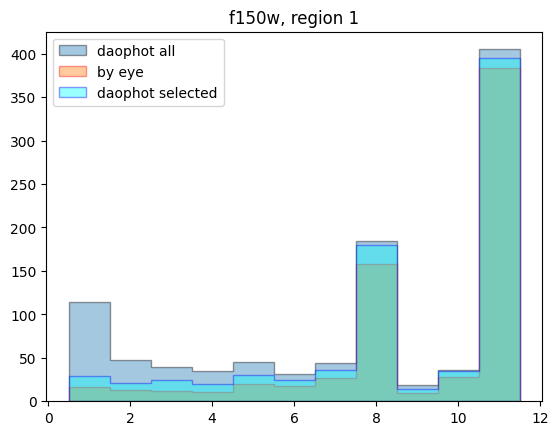

Processing filter: f210m
Number of sources before cutting: 1316
Number of sources after cutting: 940
Number of sources removed: 376
Fraction of sources removed: 28.57%


/scratch/local/25862348/ipykernel_1558182/842181764.py:34: RuntimeWarning: invalid value encountered in log10
  lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &


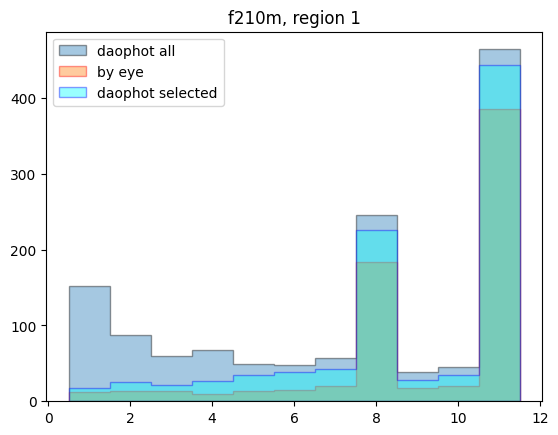

Processing filter: f212n
Number of sources before cutting: 646
Number of sources after cutting: 528
Number of sources removed: 118
Fraction of sources removed: 18.27%


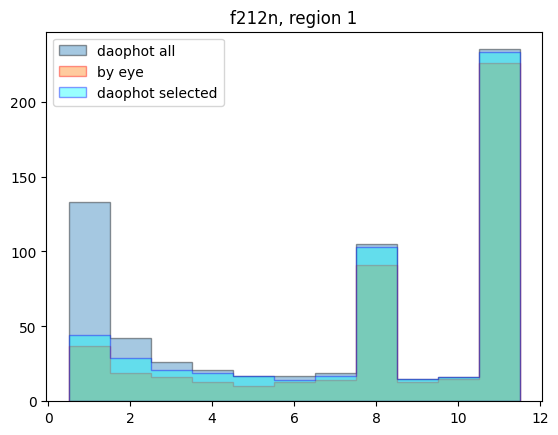

Processing filter: f300m
Number of sources before cutting: 662
Number of sources after cutting: 433
Number of sources removed: 229
Fraction of sources removed: 34.59%


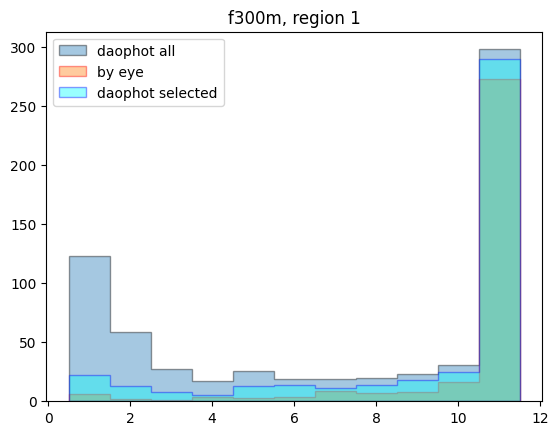

Processing filter: f360m
Number of sources before cutting: 679
Number of sources after cutting: 253
Number of sources removed: 426
Fraction of sources removed: 62.74%
Number of sources before cutting: 599
Number of sources after cutting: 211
Number of sources removed: 388
Fraction of sources removed: 64.77%


/scratch/local/25862348/ipykernel_1558182/842181764.py:70: RuntimeWarning: invalid value encountered in log10
  lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &


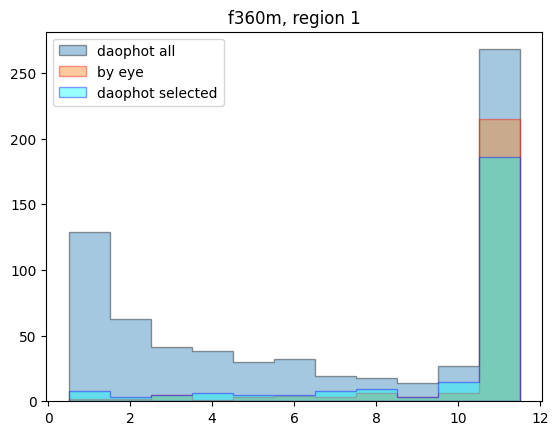

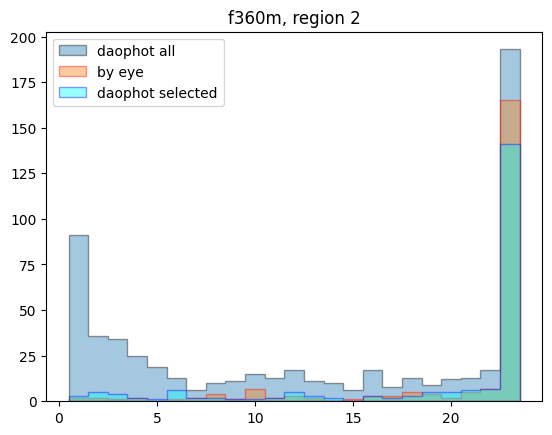

Processing filter: f405n
Number of sources before cutting: 745
Number of sources after cutting: 294
Number of sources removed: 451
Fraction of sources removed: 60.54%
Number of sources before cutting: 592
Number of sources after cutting: 308
Number of sources removed: 284
Fraction of sources removed: 47.97%


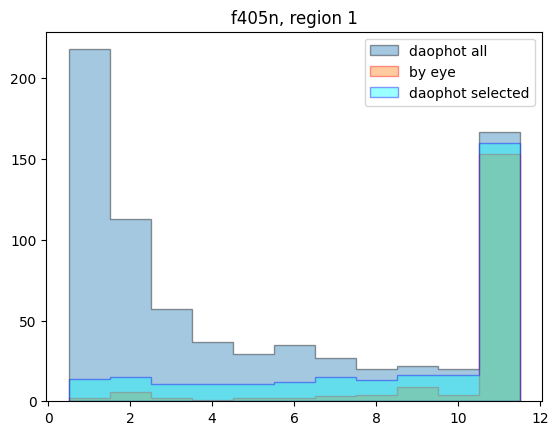

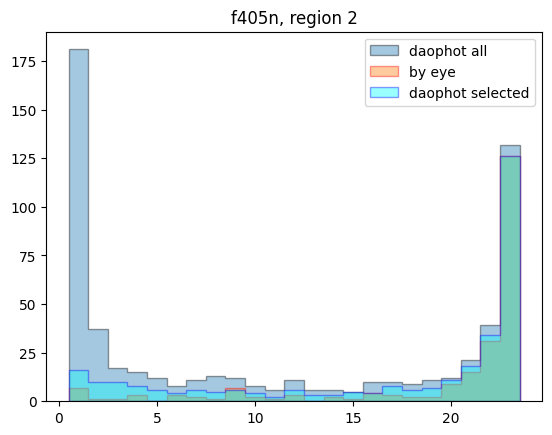

Processing filter: f410m
Number of sources before cutting: 651
Number of sources after cutting: 286
Number of sources removed: 365
Fraction of sources removed: 56.07%


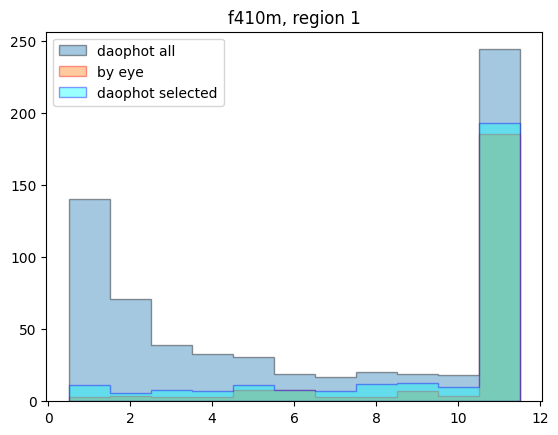

Processing filter: f466n
Number of sources before cutting: 347
Number of sources after cutting: 172
Number of sources removed: 175
Fraction of sources removed: 50.43%
Number of sources before cutting: 210
Number of sources after cutting: 104
Number of sources removed: 106
Fraction of sources removed: 50.48%


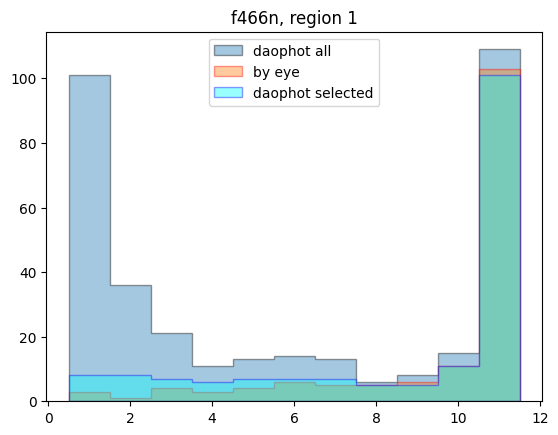

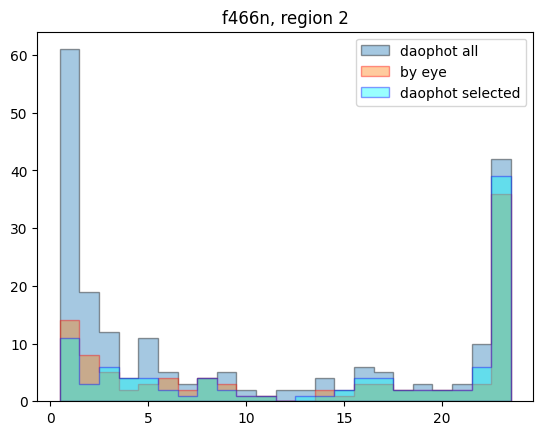

Processing filter: f480m


/scratch/local/25862348/ipykernel_1558182/842181764.py:13: RuntimeWarning: invalid value encountered in log10
  lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &


Number of sources before cutting: 556
Number of sources after cutting: 339
Number of sources removed: 217
Fraction of sources removed: 39.03%
Number of sources before cutting: 434
Number of sources after cutting: 322
Number of sources removed: 112
Fraction of sources removed: 25.81%


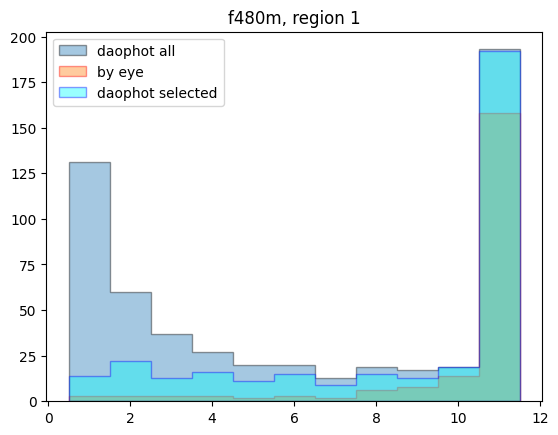

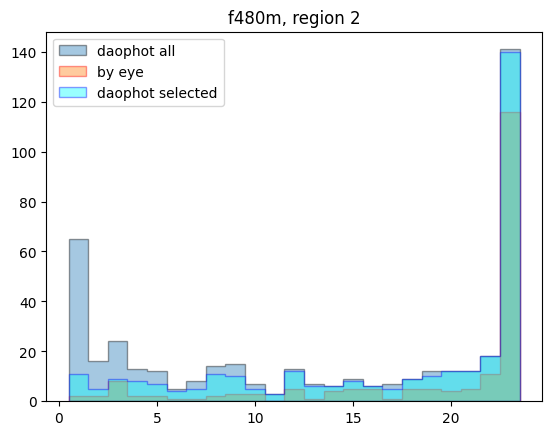

In [99]:
#182, 187
#filt_list = ['f150w', 'f210m', 'f212n', 'f300m', 'f360m', 'f405n', 'f410m', 'f466n', 'f480m']
filt_list = ['f150w', 'f210m', 'f212n', 'f300m', 'f360m', 'f405n', 'f410m', 'f466n', 'f480m']
for filt in filt_list:
    after_cut = True
    print(f"Processing filter: {filt}")
    cat_a_before_merging = Table.read(f'/orange/adamginsburg/jwst/sgrb2/NB//catalogs/{filt}_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits')
    cat_b_before_merging = Table.read(f'/orange/adamginsburg/jwst/sgrb2/NB//catalogs/{filt}_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits')
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", MergeConflictWarning)
        cats_before_merging = vstack([cat_a_before_merging, cat_b_before_merging])
    
    cats_in_region_1 = subset_catalog_in_region(cats_before_merging, test_region1, filt)
    cats_in_region_2 = subset_catalog_in_region(cats_before_merging, test_region2, filt)


    regs_region2 = None
    regs_region1_path = f"/orange/adamginsburg/jwst/sgrb2/NB/sgrb2_jwst/by_eye_catalogs/catalog_by_eye_region1_{filt}.crtf"
    regs_region1 = regions.Regions.read(regs_region1_path, format="crtf")
    try:
        regs_region2 = regions.Regions.read(f"/orange/adamginsburg/jwst/sgrb2/NB/sgrb2_jwst/by_eye_catalogs/catalog_by_eye_region2_{filt}.crtf", format="crtf")
    except FileNotFoundError:
        regs_region2 = None

    cat_in_region_1 = subset_catalog_in_region(
        cat_a_before_merging, test_region1, filt
    )

    matched_cat_a = match_regions_to_catalog(
        cat_a_before_merging, regs_region1, filt
    )

    if regs_region2 is not None:

        # Select region of interest
        cat_in_region_2 = subset_catalog_in_region(
            cat_b_before_merging, test_region2, filt
        )

        # Match by-eye regions to full catalog
        matched_cat_b = match_regions_to_catalog(
            cat_b_before_merging, regs_region2, filt
        )


    cats_in_region_1_selection = apply_filter_cuts(cats_in_region_1, filt)
    if regs_region2 is not None:
        cats_in_region_2_selection = apply_filter_cuts(cats_in_region_2, filt)
    
    
    plt.hist(cat_in_region_1['nmatch']-0.5, bins=(np.max(cat_in_region_1['nmatch'])-1), alpha=0.4, label='daophot all', edgecolor='k', histtype = 'stepfilled',)
    plt.hist(matched_cat_a['nmatch']-0.5, bins=(np.max(matched_cat_a['nmatch'])-1), alpha=0.4, label='by eye', edgecolor='r', histtype = 'stepfilled',)
    if after_cut:
        plt.hist(cats_in_region_1_selection['nmatch']-0.5, bins=(np.max(cats_in_region_1_selection['nmatch'])-1), alpha=0.4, label='daophot selected', color = 'cyan', edgecolor = 'blue', histtype = 'stepfilled',)
    plt.legend()
    plt.title(f"{filt}, region 1")
    plt.show()
    if regs_region2 is not None:
        plt.hist(cat_in_region_2['nmatch']-0.5, bins=(np.max(cat_in_region_2['nmatch'])-1), alpha=0.4, label='daophot all', edgecolor='k', histtype = 'stepfilled',)
        plt.hist(matched_cat_b['nmatch']-0.5, bins=(np.max(matched_cat_b['nmatch'])-1), alpha=0.4, label='by eye', edgecolor='r', histtype = 'stepfilled',)
        if after_cut:
            plt.hist(cats_in_region_2_selection['nmatch']-0.5, bins=(np.max(cats_in_region_2_selection['nmatch'])-1), alpha=0.4, label='daophot selected', color = 'cyan', edgecolor = 'blue', histtype = 'stepfilled',)
        plt.legend()
        plt.title(f"{filt}, region 2")
        plt.show()

    


In [76]:
filt = 'f410m'

In [78]:
regs_region2_path = None
#regs_region2_path = f"/orange/adamginsburg/jwst/sgrb2/NB/sgrb2_jwst/by_eye_catalogs/catalog_by_eye_region2_{filt}.crtf"
regs_region1_path = f"/orange/adamginsburg/jwst/sgrb2/NB/sgrb2_jwst/by_eye_catalogs/catalog_by_eye_region1_{filt}.crtf"
regs_region1 = regions.Regions.read(regs_region1_path, format="crtf")

if regs_region2_path is not None:
    regs_region2 = regions.Regions.read(regs_region2_path, format="crtf")
    regs_region_combined = Regions(list(regs_region1) + list(regs_region2))



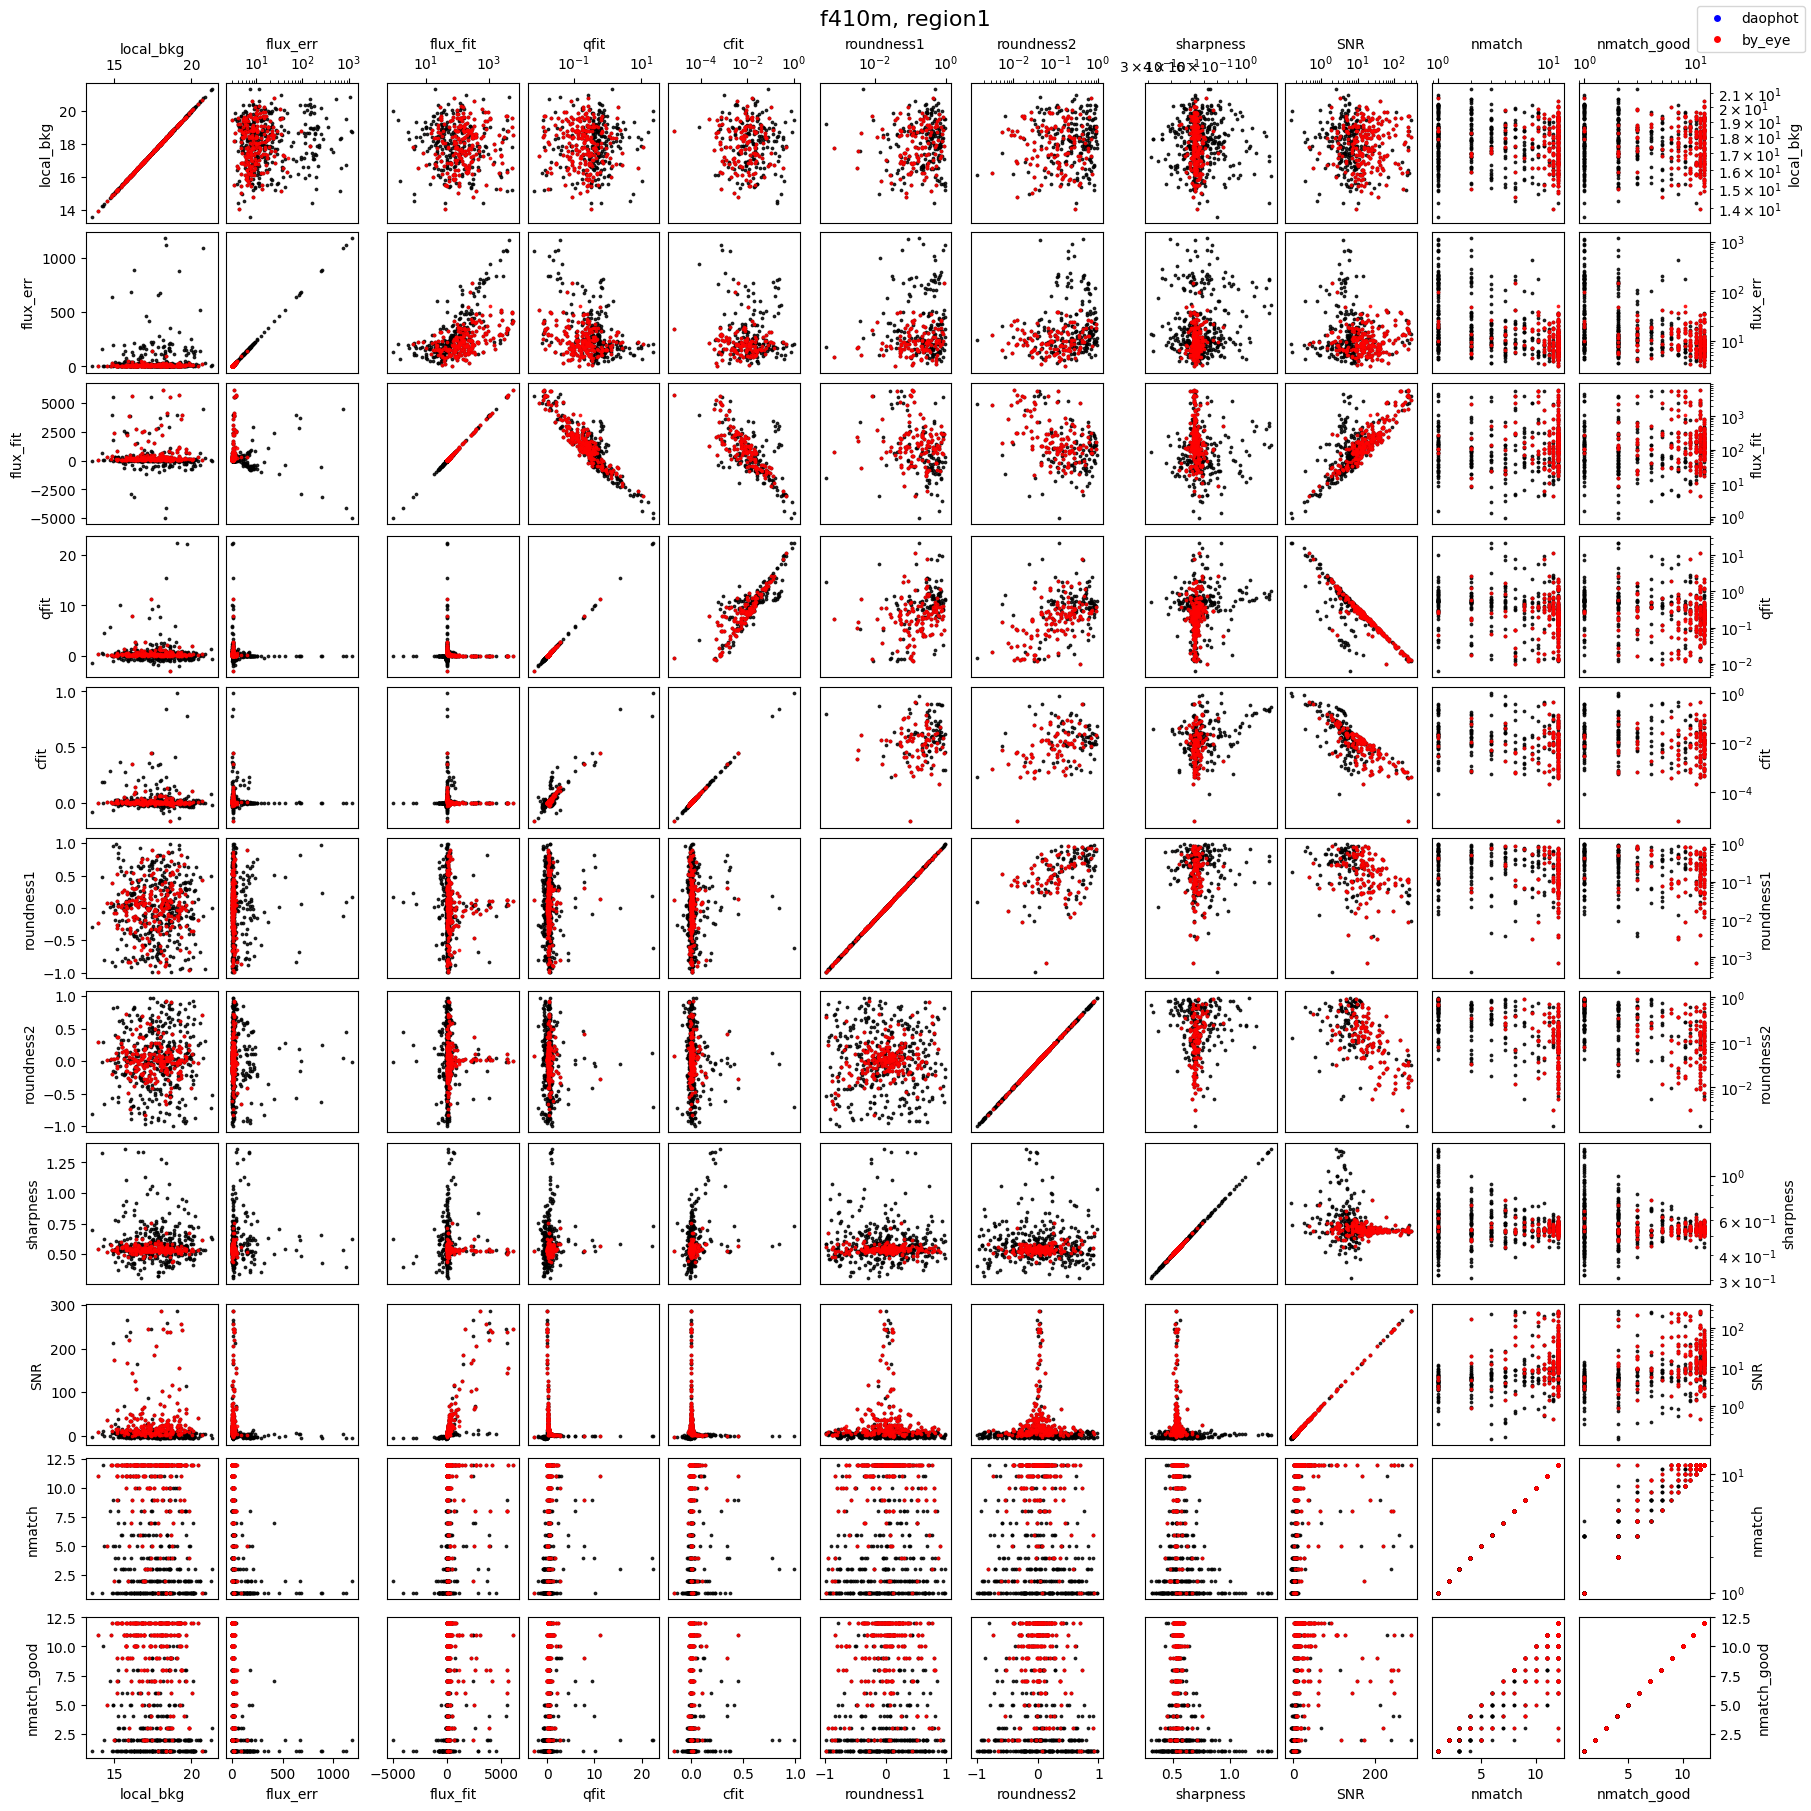

In [79]:

# Select region of interest
cat_in_region_1 = subset_catalog_in_region(
    cat_a_before_merging, test_region1, filt
)

# Match by-eye regions to full catalog
matched_cat_a = match_regions_to_catalog(
    cat_a_before_merging, regs_region1, filt
)

# Plot
fig, axes = plot_pair_matrix(
    cat_in_region_1,
    matched_cat_a,
    filt,
    title=f"{filt}, region1"
)

In [81]:
if regs_region2_path is not None:

    # Select region of interest
    cat_in_region_2 = subset_catalog_in_region(
        cat_b_before_merging, test_region2, filt
    )

    # Match by-eye regions to full catalog
    matched_cat_b = match_regions_to_catalog(
        cat_b_before_merging, regs_region2, filt
    )

    # Plot
    fig, axes = plot_pair_matrix(
        cat_in_region_2,
        matched_cat_b,
        filt,
        title=f"{filt}, region2"
)

In [82]:
# diagnostic plots

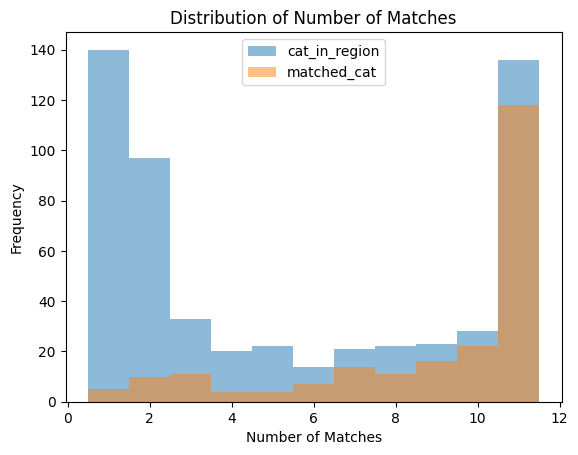

In [83]:
plt.hist(cat_in_region_1['nmatch_good']-0.5, bins=(np.max(cat_in_region_1['nmatch_good'])-1), alpha=0.5, label='cat_in_region')
plt.hist(matched_cat_a['nmatch_good']-0.5, bins=(np.max(matched_cat_a['nmatch_good'])-1), alpha=0.5, label='matched_cat')
plt.xlabel('Number of Matches')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Matches')
plt.legend()
plt.show()  

In [84]:
SNR = (cat_in_region_1['flux_fit']/cat_in_region_1['flux_err'])
qfit = cat_in_region_1['qfit']
SNR_ = matched_cat_a['flux_fit']/matched_cat_a['flux_err']
qfit_ = matched_cat_a['qfit']

Text(0, 0.5, 'qfit')

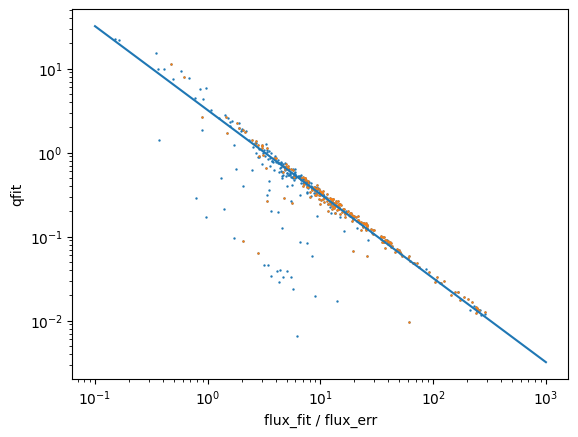

In [85]:
plt.scatter(SNR, qfit, marker = '.', s = 2)
plt.scatter(SNR_, qfit_, marker = '.', s = 2 )    
x = np.logspace(-1,3,100)
a = -1  # slope in log-log
k = 3.2   # multiplicative constant
y = k * x**a  # pure power law
plt.plot(x,y)
plt.loglog()
plt.xlabel("flux_fit / flux_err")
plt.ylabel("qfit")

In [86]:
#a = -1
#k = 3.2 
#np.log10(qfit / k * SNR**a) > 0.25

/scratch/local/25862348/ipykernel_1558182/3934018575.py:14: RuntimeWarning: invalid value encountered in log10
  log_dev = np.log10(qfit / y_pred)


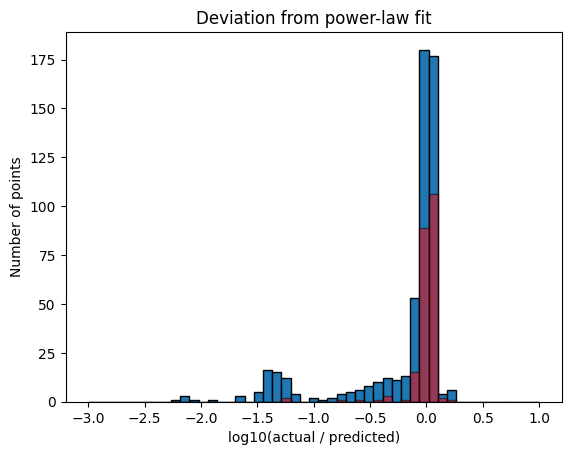

In [87]:
bins = np.linspace(-3,1, 50)
# Power-law fit parameters
a = -1
k = 3.2

# Combined arrays for convenience

# Predicted values from power law
y_pred = k * SNR**a
y_pred_ = k * SNR_**a

# Compute deviation in log space
# log(qfit) - log(y_pred) = log(actual/predicted)
log_dev = np.log10(qfit / y_pred)
log_dev_ = np.log10(qfit_ / y_pred_)

# Plot histogram of deviations
plt.hist(log_dev, bins=bins, edgecolor='black')
plt.hist(log_dev_, bins=bins, edgecolor='black', alpha=0.5, color='red')
plt.xlabel('log10(actual / predicted)')
plt.ylabel('Number of points')
plt.title('Deviation from power-law fit')
plt.show()

In [44]:
#cat_b_before_merging_ = apply_selection(cat_b_before_merging, cuts)

In [45]:


cat_in_regions = subset_catalog_in_region(
    cats_before_merging, test_regions, filt
)

cat_in_region_a = subset_catalog_in_region(
    cats_before_merging, test_region1, filt
)

cat_in_region_b = subset_catalog_in_region(
    cats_before_merging, test_region2, filt
)

In [46]:
# matched_cats = match_regions_to_catalog(
#     cats_before_merging, regs_region_combined, filt
# )

# matched_cat_a = match_regions_to_catalog(
#     cats_before_merging, regs_region1, filt
# )
# matched_cat_b = match_regions_to_catalog(
#     cats_before_merging, regs_region2, filt
# )

In [ ]:
a = -1
k = 3.2
cuts_by_filter = {
    "f480m": [
        lambda c: (c['sharpness'] > 0.4) & (c['sharpness'] < 0.7),
        #lambda c: c['flux_err'] < 300,
        lambda c: c['flux_fit'] > 0,
        ###lambda c: c['nmatch'] > 1,
        lambda c: (c['flux_fit'] / c['flux_err']) > 1,
        lambda c: (c['roundness2'] > -0.8) & (c['roundness2'] < 0.8),
        lambda c: (c['qfit'] > 0),
        lambda c: (c['cfit'] < 0.3),
        lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &
                   ((c['flux_fit'] / c['flux_err']) < 8))
    ],

    "f150w": [
        lambda c: (c['sharpness'] > 0.6) & (c['sharpness'] < 0.9),
        lambda c: c['flux_fit'] > 0,
        ###lambda c: c['nmatch'] > 1,
        lambda c: (c['roundness2'] > -0.8) & (c['roundness2'] < 0.8),
        lambda c: (0 < c['qfit']) & (c['qfit'] < 1),
        lambda c: ~((c['local_bkg'] > 3) & (c['flux_fit'] < 200)),
    ],

    "f210m": [
        lambda c: (c['sharpness'] > 0.5) & (c['sharpness'] < 0.8),
        lambda c: c['flux_fit'] > 0,
        ###lambda c: c['nmatch'] > 1,
        lambda c: (c['flux_fit'] / c['flux_err']) > 2,
        lambda c: (c['roundness2'] > -0.6) & (c['roundness2'] < 0.6),
        lambda c: (0 < c['qfit']) & (c['qfit'] < 1),
        lambda c: ~((c['local_bkg'] > 9) & (c['flux_fit'] < 1000)),
        lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &
                  ((c['flux_fit'] / c['flux_err']) < 8))
    ],

    "f405n": [
        lambda c: (c['sharpness'] > 0.5) & (c['sharpness'] < 0.75),
        lambda c: c['flux_fit'] > 0,
        ###lambda c: c['nmatch'] > 3,
        lambda c: (c['flux_fit'] / c['flux_err']) > 1,
        lambda c: (c['roundness2'] > -0.6) & (c['roundness2'] < 0.6),
    ],

    "f300m": [
        lambda c: (c['sharpness'] > 0.7) & (c['sharpness'] < 0.9),
        #lambda c: c['flux_err'] < 100,
        lambda c: c['flux_fit'] > 0,
        ###lambda c: c['nmatch'] > 3,
        lambda c: (c['flux_fit'] / c['flux_err']) > 1,
        lambda c: (c['roundness2'] > -0.6) & (c['roundness2'] < 0.6),
    ],

    "f212n": [
        lambda c: c['sharpness'] < 0.8,
        lambda c: c['flux_fit'] > 0,
        lambda c: (c['flux_fit'] / c['flux_err']) > 4,
        lambda c: (c['roundness2'] > -0.6) & (c['roundness2'] < 0.6),
        lambda c: (c['cfit'] < 0.1),
        lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &
                  ((c['flux_fit'] / c['flux_err']) < 8))
    ],
    "f360m": [
        lambda c: (c['sharpness'] > 0.4) & (c['sharpness'] < 0.7),
        lambda c: c['flux_fit'] > 0,
        lambda c: (c['flux_fit'] / c['flux_err']) > 4,
        lambda c: (c['roundness2'] > -0.6) & (c['roundness2'] < 0.6),
        lambda c: (c['cfit'] < 0.1),
        lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &
                  ((c['flux_fit'] / c['flux_err']) < 8))
    ],
    "f466n": [
        lambda c: (c['sharpness'] > 0.4) & (c['sharpness'] < 0.65),
        lambda c: c['flux_fit'] > 0,
        lambda c: (c['flux_fit'] / c['flux_err']) > 5,
        lambda c: (c['roundness2'] > -0.6) & (c['roundness2'] < 0.6),
        lambda c: (c['cfit'] < 0.1),
        lambda c: (c['qfit'] > 0),
        lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &
                  ((c['flux_fit'] / c['flux_err']) < 8))
    ],
    "f410m": [
        lambda c: (c['sharpness'] > 0.45) & (c['sharpness'] < 0.65),
        lambda c: c['flux_fit'] > 0,
        lambda c: (c['flux_fit'] / c['flux_err']) > 3,
        lambda c: (c['qfit'] > 0),
        lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &
                  ((c['flux_fit'] / c['flux_err']) < 8))
    ],

    ### temp, based on guesses!!!
    "f182m": [
        lambda c: (c['sharpness'] > 0.5) & (c['sharpness'] < 0.85),
        lambda c: c['flux_fit'] > 0,
        lambda c: (c['flux_fit'] / c['flux_err']) > 2,
        lambda c: (c['roundness2'] > -0.7) & (c['roundness2'] < 0.7),
        lambda c: (0 < c['qfit']) & (c['qfit'] < 1),
        lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &
                ((c['flux_fit'] / c['flux_err']) < 8))
    ],
    "f187n": [
        lambda c: (c['sharpness'] > 0.45) & (c['sharpness'] < 0.8),
        lambda c: c['flux_fit'] > 0,
        lambda c: (c['flux_fit'] / c['flux_err']) > 3,
        lambda c: (c['roundness2'] > -0.7) & (c['roundness2'] < 0.7),
        lambda c: (c['cfit'] < 0.15),
        lambda c: (c['qfit'] > 0),
        lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &
                ((c['flux_fit'] / c['flux_err']) < 8))
],#### 
}

def apply_filter_cuts(cat, filt):
    cuts = cuts_by_filter[f"{filt}"]
    
    mask = np.ones(len(cat), dtype=bool)
    for cut in cuts:
        mask &= cut(cat)
    print(f"Number of sources before cutting: {len(cat)}")
    print(f"Number of sources after cutting: {np.sum(mask)}")
    print(f"Number of sources removed: {len(cat) - np.sum(mask)}")
    print(f"Fraction of sources removed: {(len(cat) - np.sum(mask)) / len(cat):.2%}")
    return cat[mask]

In [95]:
cats_in_region_1 = subset_catalog_in_region(
    cats_before_merging, test_region1, filt
)
if regs_region2_path is not None:
    cats_in_region_2 = subset_catalog_in_region(
        cats_before_merging, test_region2, filt
    )

In [96]:
cats_in_region_1_selection = apply_filter_cuts(cats_in_region_1, filt)
if regs_region2_path is not None:
    cats_in_region_2_selection = apply_filter_cuts(cats_in_region_2, filt)

Number of sources before cutting: 556
Number of sources after cutting: 303
Number of sources removed: 253
Fraction of sources removed: 45.50%


/scratch/local/25862348/ipykernel_1558182/842181764.py:88: RuntimeWarning: invalid value encountered in log10
  lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &


Set DATE-AVG to '2024-09-07T16:21:01.379' from MJD-AVG.
Set DATE-END to '2024-09-07T17:05:17.716' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -4.647443 from OBSGEO-[XYZ].
Set OBSGEO-H to 1298271102.952 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Number of daophot sources: 556
Number of by-eye matched sources: 222


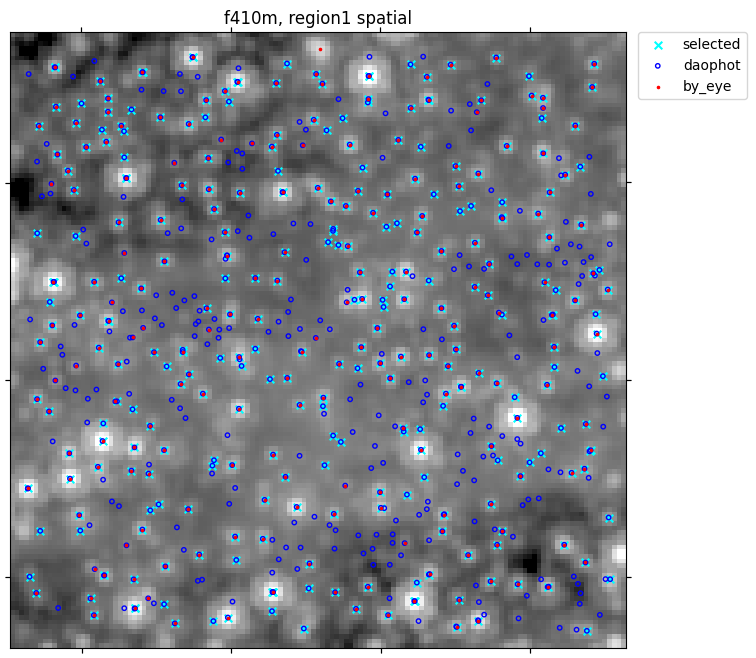

In [97]:
image_path = image_filenames_pipe[filt]

# Create cutout matching test_region2
cutout_data, cutout_wcs = get_region_cutout(
    filt,
    test_region1,
)

# Spatial plot
fig_spatial, ax_spatial = plot_spatial_detections(
    cutout_data,
    cutout_wcs,
    cats_in_region_1,
    matched_cat_a,
    #matched_cat,
    title=f"{filt}, region1 spatial",
    selected_cat = cats_in_region_1_selection
)

In [98]:
if regs_region2_path is not None:
    image_path = image_filenames_pipe[filt]

    cutout_data, cutout_wcs = get_region_cutout(
        filt,
        test_region2,
    )

    # Spatial plot
    fig_spatial, ax_spatial = plot_spatial_detections(
        cutout_data,
        cutout_wcs,
        cats_in_region_2,
        matched_cat_b,
        title=f"{filt}, region2 spatial",
        selected_cat = cats_in_region_2_selection
    )

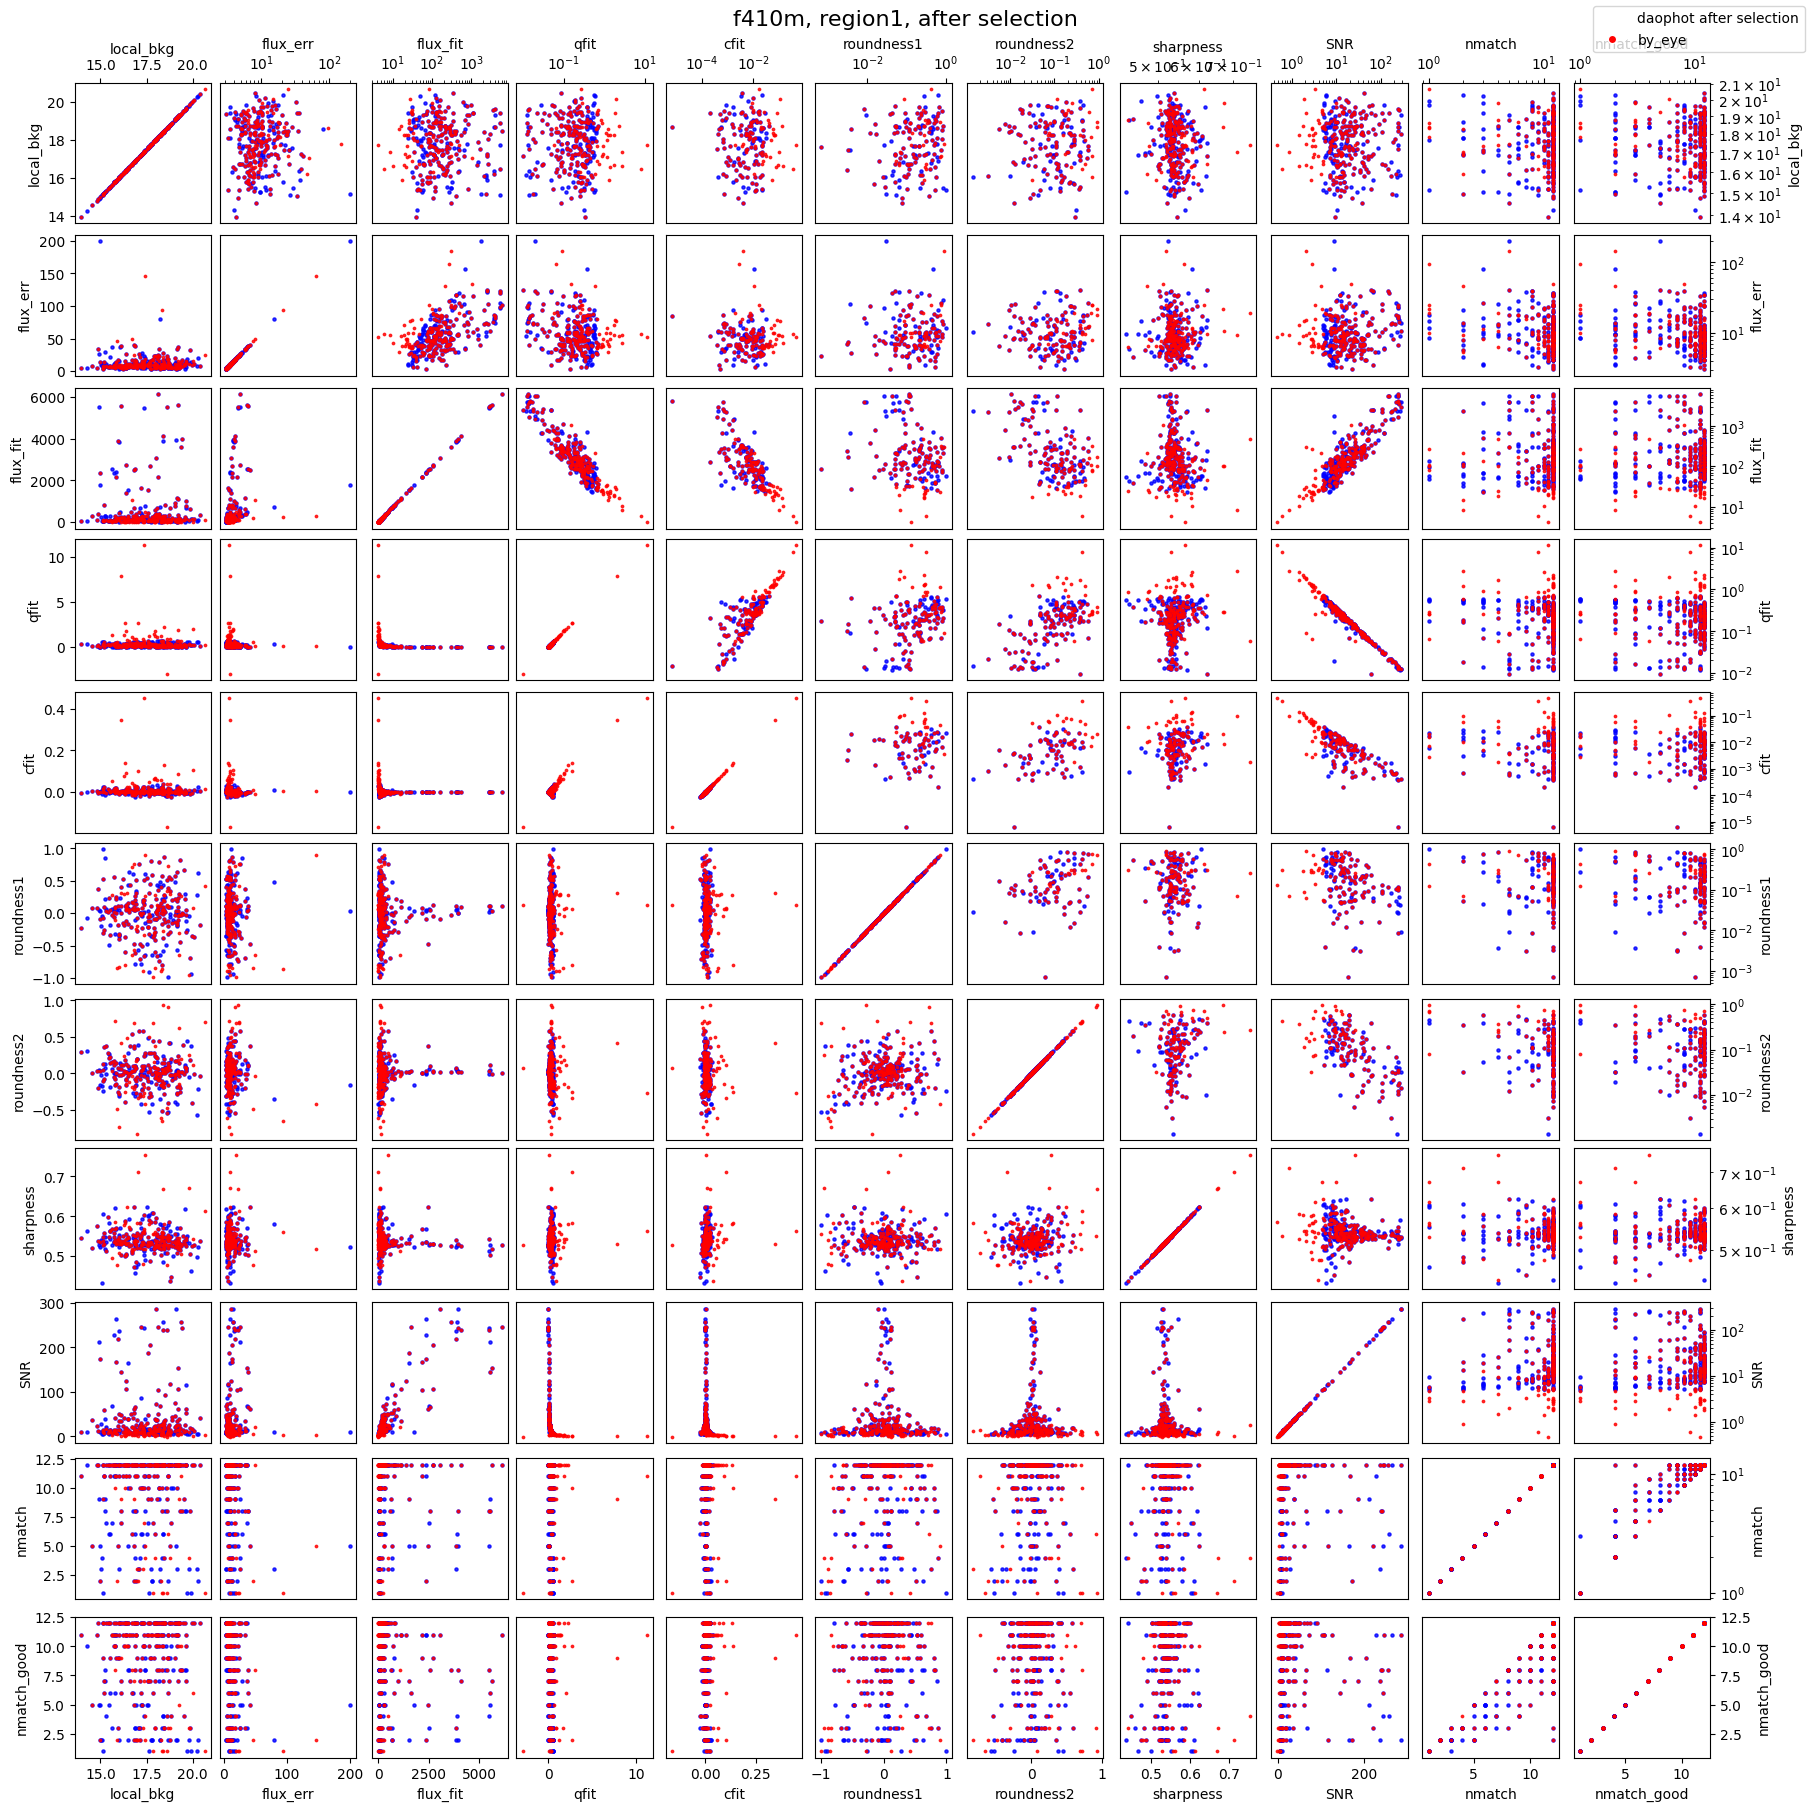

In [93]:

# Plot
fig, axes = plot_pair_matrix(
    cats_in_region_1_selection,
    matched_cat_a,
    filt,
    title=f"{filt}, region1, after selection",
    after_selection=True
)

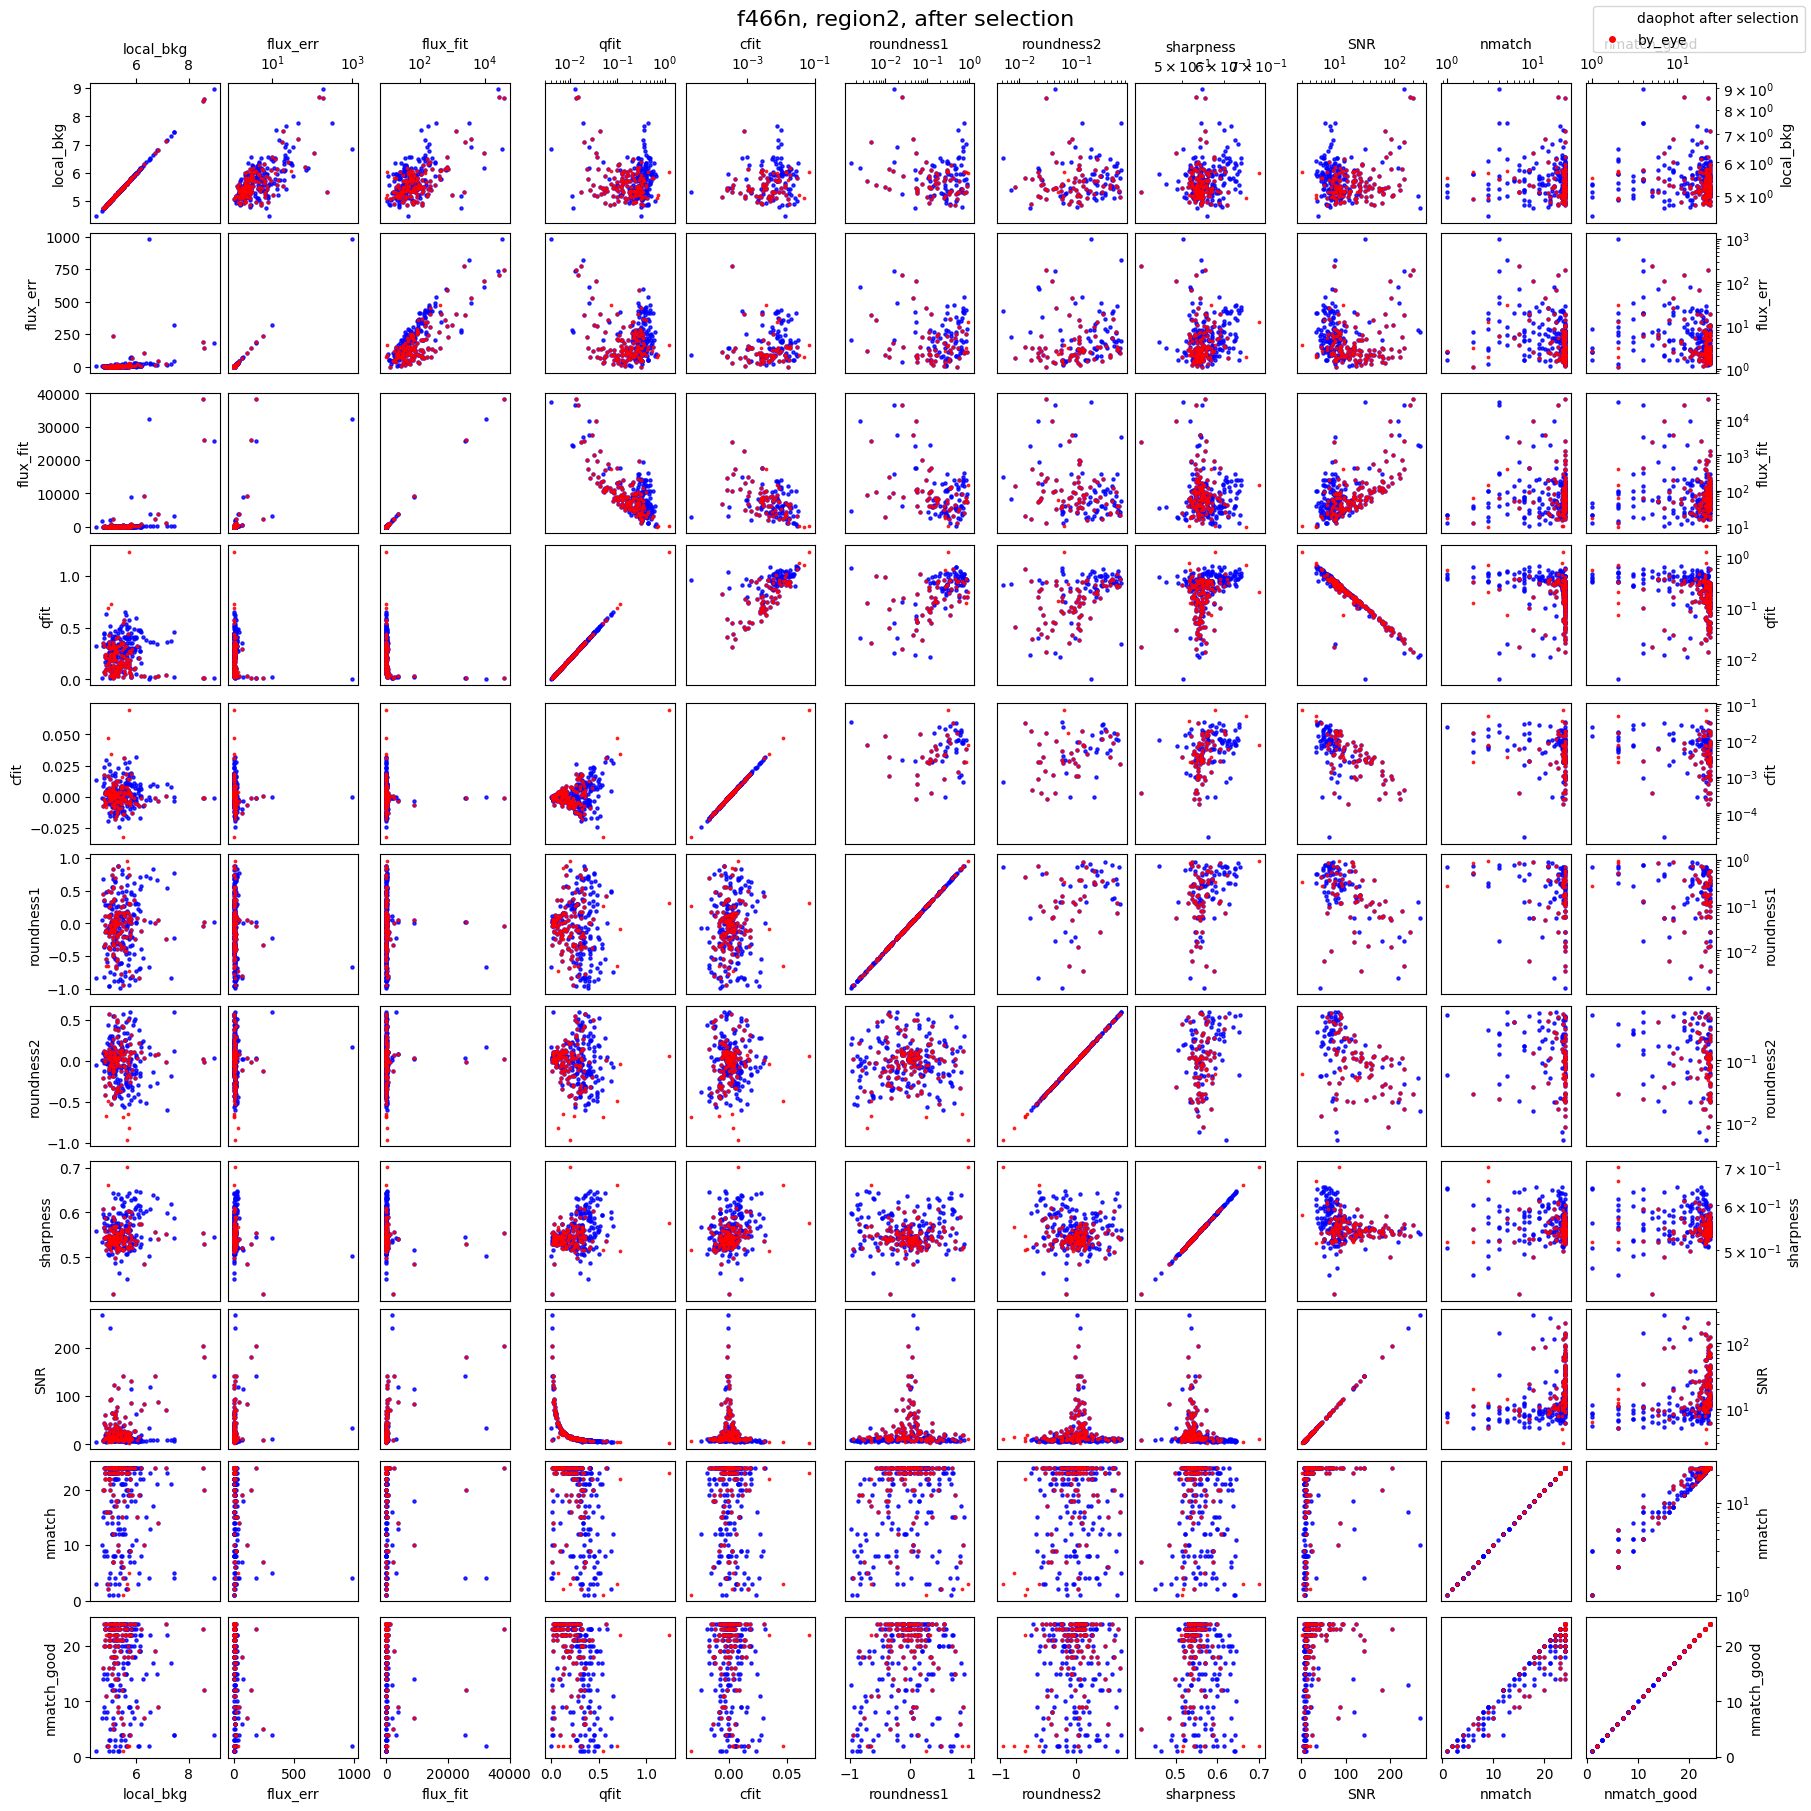

In [75]:

# Plot
fig, axes = plot_pair_matrix(
    cats_in_region_2_selection,
    matched_cat_b,
    filt,
    title=f"{filt}, region2, after selection",
    after_selection=True
)

In [102]:
filt_list_temp = ['f150w', 'f182m', 'f187n', 'f210m', 'f212n', 'f300m', 'f360m', 'f405n', 'f410m', 'f466n', 'f480m']

In [105]:
for filt in filt_list_temp:
    cat_a = Table.read(f'/orange/adamginsburg/jwst/sgrb2/NB//catalogs/{filt}_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits')
    cat_b = Table.read(f'/orange/adamginsburg/jwst/sgrb2/NB//catalogs/{filt}_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits')
    cat_a_filtered = apply_filter_cuts(cat_a, filt)
    cat_b_filtered = apply_filter_cuts(cat_b, filt)
    cat_a_filtered.write(f'/orange/adamginsburg/jwst/sgrb2/NB//catalogs/{filt}_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_filtered.fits', overwrite=True)
    cat_b_filtered.write(f'/orange/adamginsburg/jwst/sgrb2/NB//catalogs/{filt}_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_filtered.fits', overwrite=True)

Number of sources before cutting: 346703
Number of sources after cutting: 242022
Number of sources removed: 104681
Fraction of sources removed: 30.19%
Number of sources before cutting: 336075
Number of sources after cutting: 227561
Number of sources removed: 108514
Fraction of sources removed: 32.29%


/scratch/local/25862348/ipykernel_1558182/2526822004.py:99: RuntimeWarning: invalid value encountered in log10
  lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &


Number of sources before cutting: 435433
Number of sources after cutting: 339854
Number of sources removed: 95579
Fraction of sources removed: 21.95%
Number of sources before cutting: 413200
Number of sources after cutting: 321368
Number of sources removed: 91832
Fraction of sources removed: 22.22%


/scratch/local/25862348/ipykernel_1558182/2526822004.py:109: RuntimeWarning: invalid value encountered in log10
  lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &


Number of sources before cutting: 556167
Number of sources after cutting: 299820
Number of sources removed: 256347
Fraction of sources removed: 46.09%
Number of sources before cutting: 548477
Number of sources after cutting: 290495
Number of sources removed: 257982
Fraction of sources removed: 47.04%


...

Number of sources before cutting: 237999
Number of sources after cutting: 104407
Number of sources removed: 133592
Fraction of sources removed: 56.13%
Number of sources before cutting: 231223
Number of sources after cutting: 102750
Number of sources removed: 128473
Fraction of sources removed: 55.56%


/scratch/local/25862348/ipykernel_1558182/2526822004.py:80: RuntimeWarning: invalid value encountered in log10
  lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &


Number of sources before cutting: 97199
Number of sources after cutting: 57155
Number of sources removed: 40044
Fraction of sources removed: 41.20%
Number of sources before cutting: 94467
Number of sources after cutting: 53724
Number of sources removed: 40743
Fraction of sources removed: 43.13%


/scratch/local/25862348/ipykernel_1558182/2526822004.py:13: RuntimeWarning: invalid value encountered in log10
  lambda c: ~((np.log10(c['qfit'] / (k * (c['flux_fit'] / c['flux_err'])**a)) < -0.3) &


Number of sources before cutting: 182723
Number of sources after cutting: 129383
Number of sources removed: 53340
Fraction of sources removed: 29.19%
Number of sources before cutting: 189111
Number of sources after cutting: 131288
Number of sources removed: 57823
Fraction of sources removed: 30.58%


In [ ]:
MAKE HISTOGRAM OF NMATCH FOR EVERY BY EYE CATALOG

In [ ]:
aaa

In [ ]:
def subset_catalog_in_region(cat, regions, filt):
    coords = cat["skycoord"]
    # Start with all False
    mask = np.zeros(len(cat), dtype=bool)
    if isinstance(regions, RectangleSkyRegion):
        mask |= regions.contains(coords, wcs=wcs.WCS(fits.getheader(image_filenames_pipe[filt], ext=1)))
    else:
        for r in regions:
            # Update mask to include points inside this region
            mask |= r.contains(coords, wcs=wcs.WCS(fits.getheader(image_filenames_pipe[filt], ext=1)))
            
    return cat[mask]

In [ ]:
def match_regions_to_catalog(cat, regions_list, 
                             coord_col="skycoord",
                             max_sep=0.1*u.arcsec):
    matched_indices = []

    for reg in regions_list:
        idx, sep2d, _ = reg.center.match_to_catalog_sky(cat[coord_col])
        if sep2d < max_sep:
            matched_indices.append(idx)

    return cat[matched_indices]

In [ ]:
def build_plot_columns(cat):
    plot_cols = {
        "local_bkg": cat["local_bkg"],
        "flux_err": cat["flux_err"],
        "flux_fit": cat["flux_fit"],
        "qfit": cat["qfit"],
        "cfit": cat["cfit"],
        "roundness1": cat["roundness1"],
        "roundness2": cat["roundness2"],
        "sharpness": cat["sharpness"],
        "SNR": cat["flux_fit"] / cat["flux_err"],
        "nmatch": cat["nmatch"],
        "nmatch_good": cat['nmatch_good']
    }
    return plot_cols

In [ ]:
def plot_pair_matrix(cat_region, cat_matched, title="",
                     log_upper_triangle=True):

    plot_cols = build_plot_columns(cat_region)
    plot_cols_matched = build_plot_columns(cat_matched)

    cols = list(plot_cols.keys())
    n = len(cols)

    fig, axes = plt.subplots(n, n, figsize=(18, 18),
                             constrained_layout=True)

    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):

            ax = axes[i, j]

            x_all = plot_cols[col2]
            y_all = plot_cols[col1]

            x_match = plot_cols_matched[col2]
            y_match = plot_cols_matched[col1]

            ax.scatter(x_all, y_all, s=3, c="k")
            ax.scatter(x_match, y_match, s=3, c="red")

            if log_upper_triangle and j > i:
                ax.set_xscale("log")
                ax.set_yscale("log")

            ax.tick_params(axis='both', which='both',
                           top=False, bottom=False,
                           left=False, right=False,
                           labeltop=False, labelbottom=False,
                           labelleft=False, labelright=False)

            if i == 0:
                ax.tick_params(axis='x', which='both',
                               top=True, labeltop=True)
                ax.xaxis.set_label_position('top')
                ax.set_xlabel(col2)

            if i == n - 1:
                ax.tick_params(axis='x', which='both',
                               bottom=True, labelbottom=True)
                ax.set_xlabel(col2)

            if j == 0:
                ax.tick_params(axis='y', which='both',
                               left=True, labelleft=True)
                ax.set_ylabel(col1)

            if j == n - 1:
                ax.tick_params(axis='y', which='both',
                               right=True, labelright=True)
                ax.yaxis.set_label_position('right')
                ax.set_ylabel(col1)

    fig.suptitle(title, fontsize=16)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='k', markersize=6, label='daophot'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='red', markersize=6, label='by_eye'),
    ]

    fig.legend(handles=legend_elements)

    return fig, axes

In [ ]:
#cat480dao = cat480dao[cat480dao['flux_fit'] > 0]

In [ ]:
cat_in_region

id,group_id,group_size,local_bkg,x_init,y_init,flux_init,x_fit,y_fit,flux_fit,x_err,y_err,flux_err,npixfit,qfit,cfit,reduced_chi2,flags,skycoord_centroid,dra,ddec
,,,,,,,,,,,,,,,,,,"deg,deg",arcsec,arcsec
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,SkyCoord,float64,float64
247894,247894,1,15.193202018737793,999.3851862552493,2178.1949040954514,1652.0709584387228,997.5734491342596,2180.8781258025906,227.33558427634114,0.2494847883699563,0.5716533845313452,108.60707395158632,25,0.30181271538829907,0.030316460656447938,--,0,"266.85313979968294,-28.429854174426886",0.015694715437124262,0.03596186067097653
248127,248127,1,14.780328750610352,972.9761442630573,2179.3726242191924,1636.5643682518487,972.8718897468863,2179.5796391154195,262.7536953891838,0.14149240417395215,0.14751643634243913,25.139015685560835,25,0.34826060909838585,-0.015583370885090864,--,0,"266.85311434662356,-28.430285839815486",0.008901075831251656,0.00928003869823129
248247,248247,1,14.924076080322266,997.4528961561476,2180.277153291138,3300.688804701677,997.3398558231838,2181.200204671934,296.9473235962553,0.1232441388188679,0.1513434131089978,25.68699081406172,25,0.2951029989170209,-0.0006081122430223637,--,0,"266.8531462030179,-28.42985825236458",0.007753104711086679,0.009520788091122358
248248,248248,1,15.256754398345947,1005.4647981892023,2179.9659897119345,2231.8515884271055,1005.4152474485312,2180.004761118414,393.06125457900725,0.05255398061391402,0.05495392912749721,14.235947419743615,25,0.14761446392062857,-0.008799891764413367,--,0,"266.8531223341851,-28.429717153198325",0.003306092432378746,0.0034570696091057803
248371,248371,1,16.439971923828125,945.5432434506218,2180.7058313443717,1548.8002562846077,945.5205032078537,2180.720656522098,102.32052811789113,0.10793821991975046,0.1127463635477246,7.610287073301952,25,0.24225790190373556,-0.00664585628747903,--,0,"266.85313740662457,-28.430763779465014",0.006790232212146465,0.007092705346941259
248372,248372,1,15.475841522216797,1010.0267231820827,2181.257818883532,2478.548175838847,1010.0299385579463,2181.2614139995785,1198.582147677247,0.028823317119462115,0.0292885408131791,23.386471331247655,25,0.08064212295581771,-0.006359852331549676,--,0,"266.85314723985397,-28.429636497805106",0.0018132318330892924,0.0018424983608611924
248373,248373,1,17.189258575439453,1028.5774120152473,2179.3452501769716,1511.4118515982352,1030.8072276661042,2179.2747059253456,92.01431766319577,0.0696001620115986,0.05175545898955025,3.481845705382057,25,0.11280226486661221,0.001705562596490267,--,0,"266.8531074683615,-28.429273448219575",0.004378442246065736,0.0032558586295618978
248490,248490,1,14.738531112670898,928.1767337299746,2182.511677445547,1309.935488687776,928.2236657069332,2182.581696428021,67.01843411482825,0.11314399981465333,0.11649626936462187,5.192831952171455,25,0.24467155685410455,-0.0013569596886336664,--,0,"266.85317463236134,-28.43106601118481",0.007117720050634024,0.007328606321492647


In [ ]:
cols = list(plot_cols.keys())

# Convert to arrays and stack
data_not_matched = np.vstack([np.array(plot_cols_not_matched[k]) for k in cols]).T
data_matched = np.vstack([np.array(plot_cols_matched[k]) for k in cols]).T

# Mask out any row with NaN or Inf
mask_not_matched = np.all(np.isfinite(data_not_matched), axis=1)
mask_matched = np.all(np.isfinite(data_matched), axis=1)

data_not_matched_clean = data_not_matched[mask_not_matched]
data_matched_clean = data_matched[mask_matched]

fig = corner.corner(
    data_not_matched_clean,
    labels=cols,
    color='k',
    bins=9,
    show_titles=True,
    title_fmt=".2f",
    label_kwargs={"fontsize":12},
    axes_scale=axes_scale,smooth=0.5
    
)

# Overplot matched sources
corner.corner(
    data_matched_clean,
    labels=cols,
    color='red',
    bins=9,
    fig=fig,  # overlay
    axes_scale=axes_scale,
    smooth=0.5
)

fig.suptitle("F480M, combined regions", fontsize=16)

TypeError: object of type 'int' has no len()

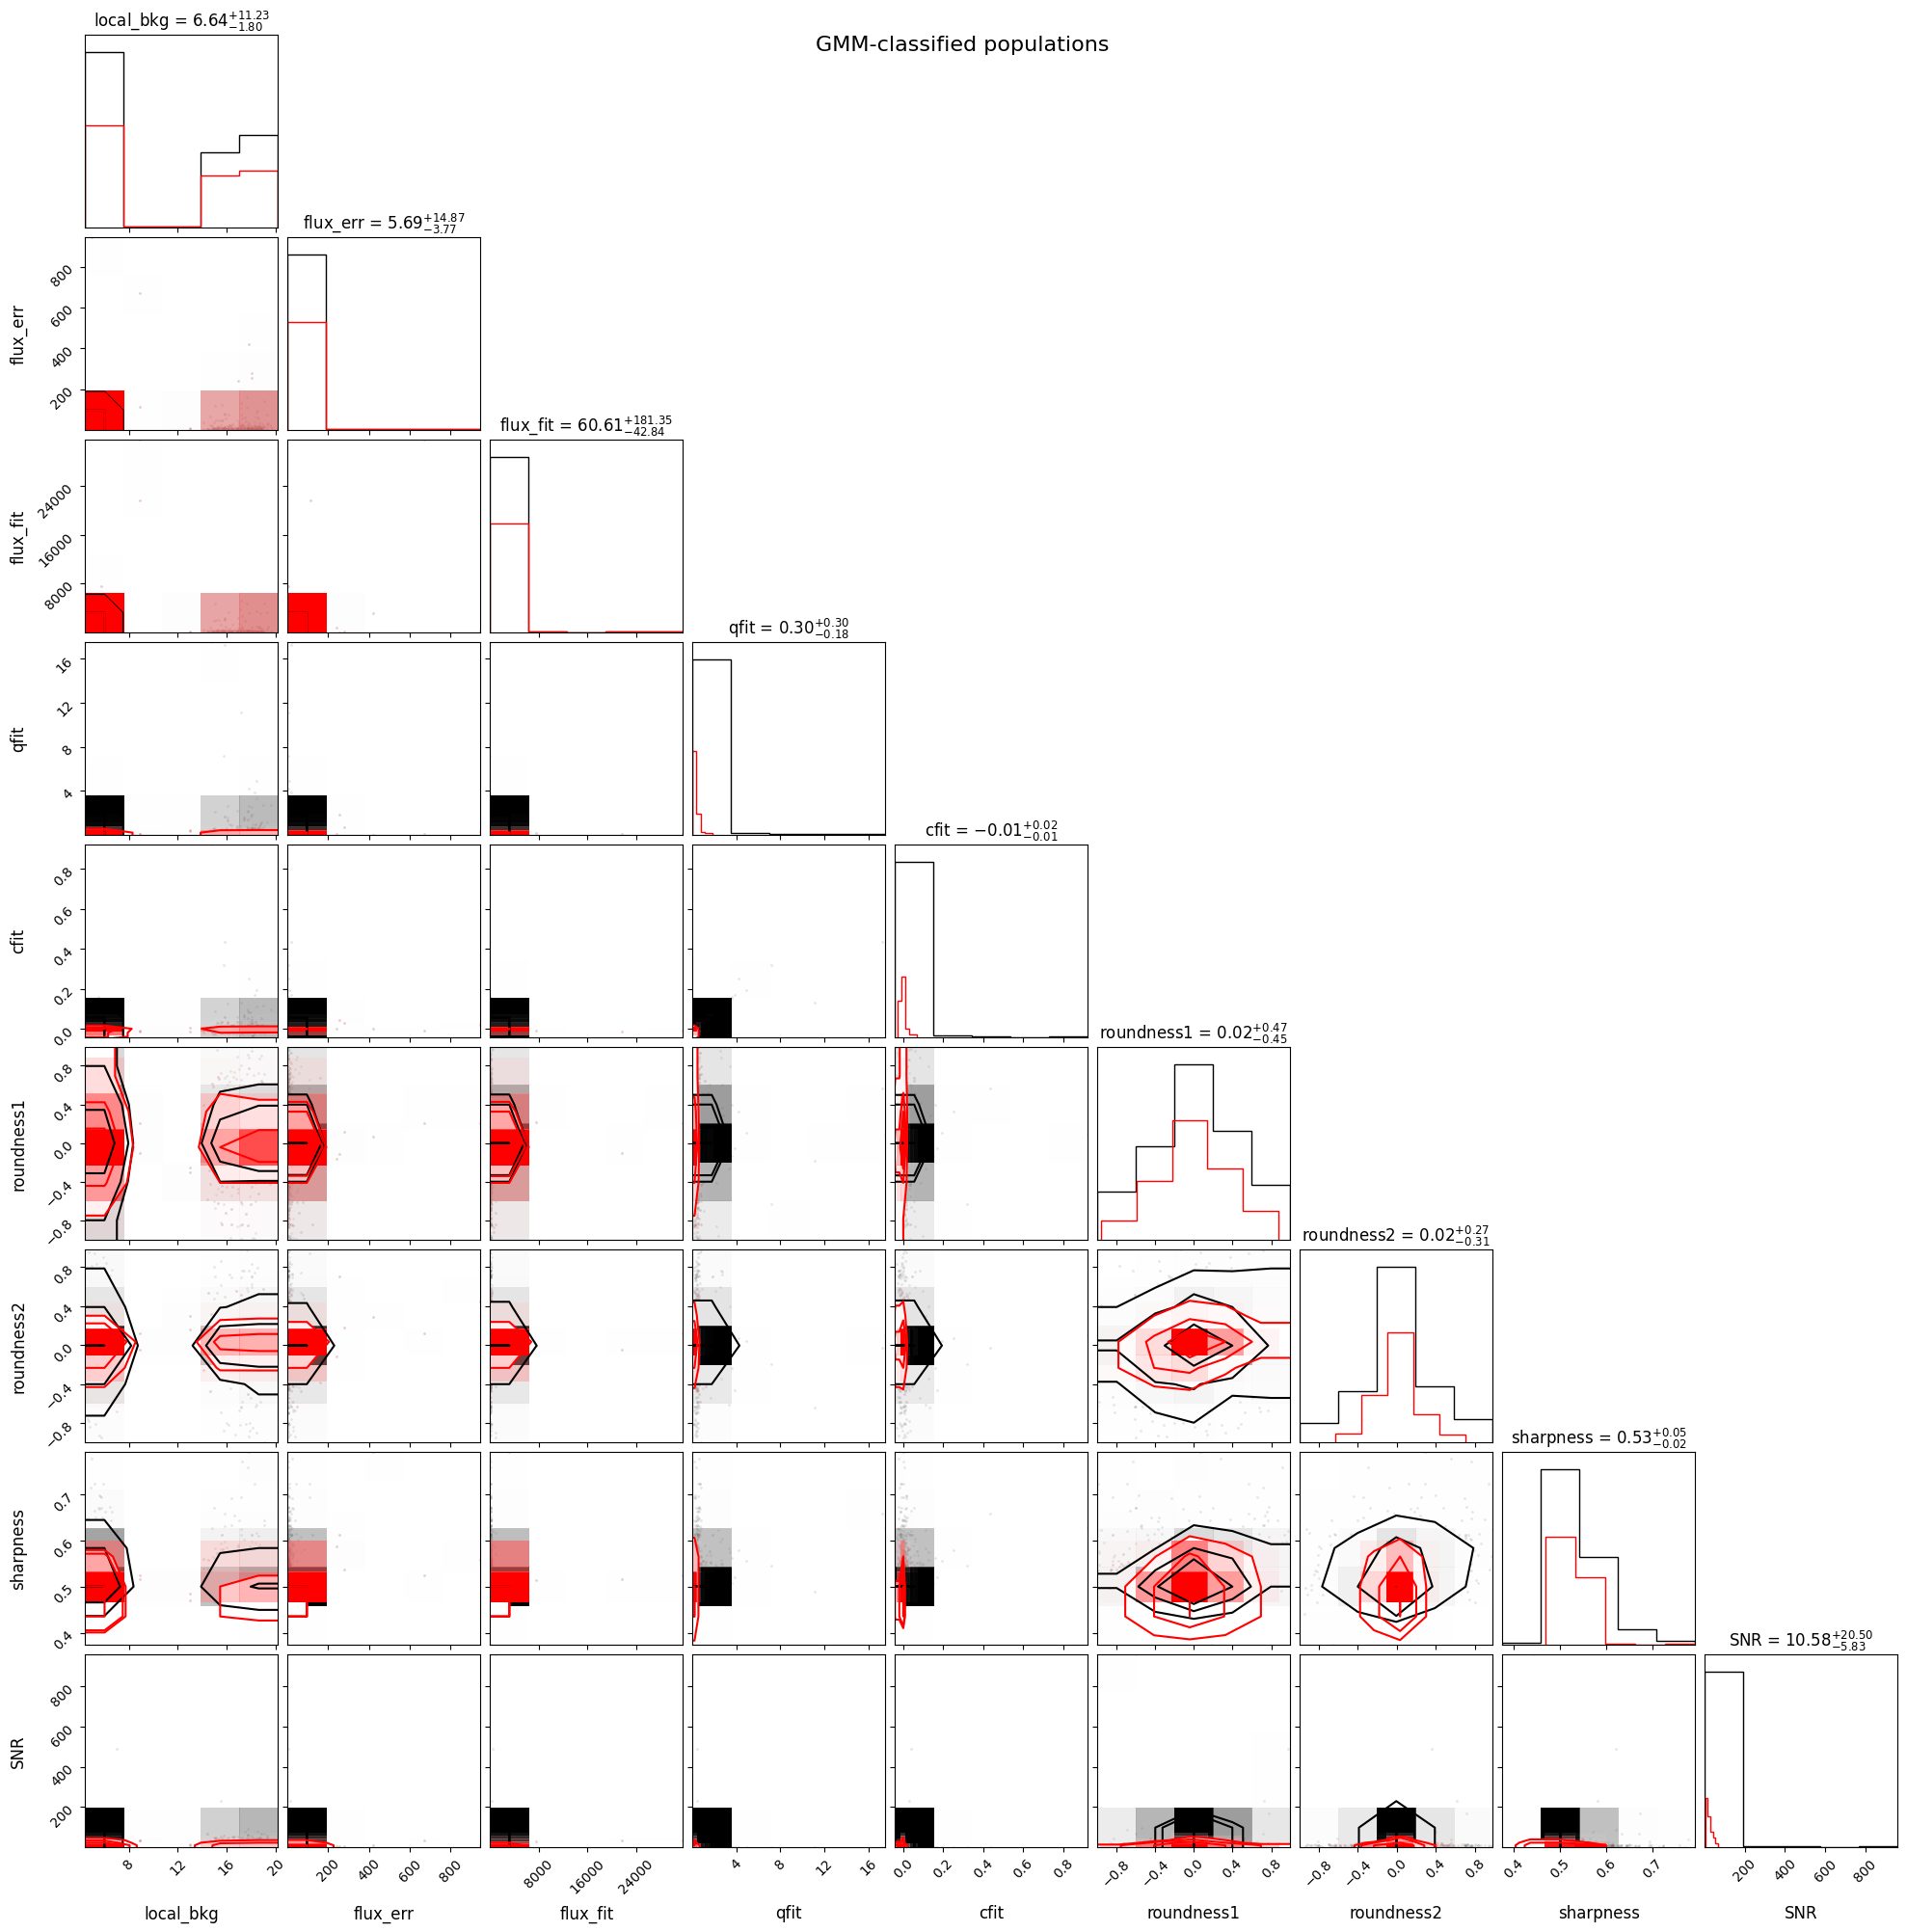

In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. Define scales and transform data
# -------------------------------


cols = list(plot_cols_not_matched.keys())

def transform_data(plot_cols_dict, cols):
    """Build data array with log transform if needed."""
    arr_list = []
    for k in cols:
        vals = np.array(plot_cols_dict[k])
        vals = vals[np.isfinite(vals)]  # remove NaN/Inf
        arr_list.append(vals)
    # Stack columns
    min_len = min(len(a) for a in arr_list)  # ensure same length
    arr_list = [a[:min_len] for a in arr_list]
    return np.vstack(arr_list).T

data_not_matched_clean = transform_data(plot_cols_not_matched, cols,)
data_matched_clean = transform_data(plot_cols_matched, cols,)

# Combine for scaling
scaler = StandardScaler()
scaler.fit(np.vstack([data_not_matched_clean, data_matched_clean]))

data_not_matched_scaled = scaler.transform(data_not_matched_clean)
data_matched_scaled = scaler.transform(data_matched_clean)

# -------------------------------
# 2. Fit one GMM per population
# -------------------------------
gmm_not_matched = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_not_matched.fit(data_not_matched_scaled)

gmm_matched = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_matched.fit(data_matched_scaled)

# -------------------------------
# 3. Compute probabilities for all points
# -------------------------------
# Example: classify new combined catalog
all_data_clean = np.vstack([data_not_matched_clean, data_matched_clean])
all_data_scaled = scaler.transform(all_data_clean)

# Probability that each point belongs to each population
logprob_not_matched = gmm_not_matched.score_samples(all_data_scaled)
logprob_matched = gmm_matched.score_samples(all_data_scaled)

# Assign to the population with higher likelihood
labels = np.where(logprob_matched > logprob_not_matched, 1, 0)  # 1=matched, 0=not matched

# -------------------------------
# 4. Optional: visualize clusters on corner plot
# -------------------------------
import corner
import matplotlib.pyplot as plt

fig = corner.corner(
    all_data_clean,
    labels=cols,
    color='k',
    bins=5,
    show_titles=True,
    title_fmt=".2f",
    label_kwargs={"fontsize":12},
    plot_contours=True,
    fill_contours=False
)

corner.corner(
    all_data_clean[labels==1],
    labels=cols,
    color='red',
    bins=5,
    fig=fig,
    plot_contours=True,
    fill_contours=False
)

fig.suptitle("GMM-classified populations", fontsize=16)
plt.show()

In [ ]:
len(data_matched_clean)

365

In [ ]:
len(data_not_matched_clean)

226

In [ ]:
len(data_not_matched)

237

In [ ]:
np.isnan(data_not_matched_scaled)[6].sum()

0

In [ ]:
axes_scale = 0

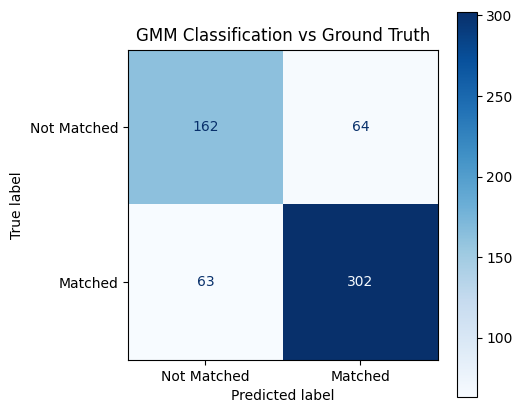

In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -------------------------------
# 1. Prepare the data and scale
# -------------------------------


cols = list(plot_cols_not_matched.keys())

def transform_data(plot_cols_dict, cols):
    """Build data array with log transform if needed."""
    arr_list = []
    for k in cols:
        vals = np.array(plot_cols_dict[k])
        vals = vals[np.isfinite(vals)]  # remove NaN/Inf
        arr_list.append(vals)
    # Stack columns
    min_len = min(len(a) for a in arr_list)  # ensure same length
    arr_list = [a[:min_len] for a in arr_list]
    return np.vstack(arr_list).T



data_not_matched_clean = transform_data(plot_cols_not_matched, cols)
data_matched_clean = transform_data(plot_cols_matched, cols)

#data_not_matched_clean = data_not_matched
#data_matched_clean = data_matched

# Scale features
scaler = StandardScaler()
scaler.fit(np.vstack([data_not_matched_clean, data_matched_clean]))

data_not_matched_scaled = scaler.transform(data_not_matched_clean)
data_matched_scaled = scaler.transform(data_matched_clean)

# -------------------------------
# 2. Fit GMMs per population
# -------------------------------
gmm_not_matched = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_not_matched.fit(data_not_matched_scaled)

gmm_matched = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm_matched.fit(data_matched_scaled)

# -------------------------------
# 3. Compute GMM labels for all points
# -------------------------------
all_data_clean = np.vstack([data_not_matched_clean, data_matched_clean])
all_data_scaled = scaler.transform(all_data_clean)

# Log-likelihood under each population
logprob_not_matched = gmm_not_matched.score_samples(all_data_scaled)
logprob_matched = gmm_matched.score_samples(all_data_scaled)

# Assign each point to the population with higher likelihood
gmm_labels = np.where(logprob_matched > logprob_not_matched, 1, 0)  # 1=matched, 0=not matched

# -------------------------------
# 4. Ground truth labels
# -------------------------------
# 0 = not matched, 1 = matched
y_true = np.hstack([np.zeros(len(data_not_matched_clean)), np.ones(len(data_matched_clean))])

# -------------------------------
# 5. Confusion matrix
# -------------------------------
cm = confusion_matrix(y_true, gmm_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Matched', 'Matched'])

plt.figure(figsize=(5,5))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("GMM Classification vs Ground Truth")
plt.show()